# Cross-State Patient Safety Comparisons
**States:** California · Colorado · Michigan · Washington
**Common window:** January 2023 – December 2024

> All graphs in this notebook use only the overlapping period shared by all four datasets.
> WA data is year-level only (no month breakdown), so monthly charts cover CA · CO · MI; WA appears in annual comparisons.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120})
sns.set_theme(style='whitegrid', palette='muted')

STATE_COLORS = {'CA': '#E53935', 'CO': '#8E24AA', 'MI': '#1E88E5', 'WA': '#43A047'}
COMMON_START, COMMON_END = 2023, 2024

In [2]:
# ── Load and immediately filter every dataset to the common window ──────────
ca_raw = pd.read_csv('../../data/source/California/CA - Final_PRA_29194 - 2026-04-08.xlsx - Detail.csv')
ca_raw['date']  = pd.to_datetime(ca_raw['RECVDATE'], errors='coerce')
ca_raw['year']  = ca_raw['date'].dt.year
ca_raw['month'] = ca_raw['date'].dt.to_period('M')
ca = ca_raw[(ca_raw.year >= COMMON_START) & (ca_raw.year <= COMMON_END)].copy()

co_raw = pd.read_csv('../../data/source/Colorado/CO - Data_Request_-_Michael_Nolan-_03.30.2026_-_Facility_Occurrences_CY_23-25xlsx.xlsx - Data.csv')
co_raw['date']  = pd.to_datetime(co_raw['Occurrence Date'], errors='coerce')
co_raw['year']  = co_raw['date'].dt.year
co_raw['month'] = co_raw['date'].dt.to_period('M')
co = co_raw[(co_raw.year >= COMMON_START) & (co_raw.year <= COMMON_END)].copy()

mi_raw = pd.read_csv('../../data/source/Michigan/MI - Critical_Incident._SUD_Sentinel_Event_FOIA_Request.1-1-23_to_1-1-25.xlsx - FOIA Request 10.1.22-3.18.26.csv')
mi_raw['date']  = pd.to_datetime(mi_raw['Date of Incident'], errors='coerce')
mi_raw['year']  = mi_raw['date'].dt.year
mi_raw['month'] = mi_raw['date'].dt.to_period('M')
mi = mi_raw[(mi_raw.year >= COMMON_START) & (mi_raw.year <= COMMON_END)].copy()

wa_raw = pd.read_csv('../../data/source/Washington/WA-downloadable_ae - 2026-04-07.csv')
wa_raw = wa_raw.drop(columns=['Percentage of Adverse Events'], errors='ignore')
wa = wa_raw[wa_raw['Year'].isin([COMMON_START, COMMON_END])].copy()

print('=== Records in common window (Jan 2023 – Dec 2024) ===')
print(f'  CA : {len(ca):,}  reports  (full dataset: {len(ca_raw):,})')
print(f'  CO : {len(co):,}  reports  (full dataset: {len(co_raw):,})')
print(f'  MI : {len(mi):,}  reports  (full dataset: {len(mi_raw):,})')
print(f'  WA : {int(wa["Adverse Event Count"].sum()):,}  events   (year-level, 2023 + 2024 only)')

=== Records in common window (Jan 2023 – Dec 2024) ===
  CA : 4,682  reports  (full dataset: 4,682)
  CO : 10,477  reports  (full dataset: 10,477)
  MI : 7,059  reports  (full dataset: 11,980)
  WA : 4,488  events   (year-level, 2023 + 2024 only)


## 1 · Dataset Overview — Common Window

In [3]:
overview = pd.DataFrame([
    {'State': 'CA', 'System': 'Hospital Adverse Events (HSC §1279.1)',
     'Window': 'Jan 2023 – Dec 2024', 'Records': f'{len(ca):,}',
     'Granularity': 'Monthly', 'Facility Types': 'General Acute Care, Acute Psychiatric'},
    {'State': 'CO', 'System': 'Facility Reportable Occurrences (CRS §25-1-124)',
     'Window': 'Jan 2023 – Dec 2024', 'Records': f'{len(co):,}',
     'Granularity': 'Monthly', 'Facility Types': 'SNF, ALR, Hospital, Psychiatric…'},
    {'State': 'MI', 'System': 'SUD Critical Incidents & Sentinel Events',
     'Window': 'Jan 2023 – Dec 2024', 'Records': f'{len(mi):,}',
     'Granularity': 'Monthly', 'Facility Types': 'Substance Use Disorder programs'},
    {'State': 'WA', 'System': 'Adverse Event Reporting (RCW 70.56)',
     'Window': 'Jan 2023 – Dec 2024', 'Records': f"{int(wa['Adverse Event Count'].sum()):,}",
     'Granularity': 'Yearly only', 'Facility Types': 'ASF, Acute Care, Birthing Centers, Psychiatric'},
])
print(overview.to_string(index=False))

State                                          System              Window Records Granularity                                 Facility Types
   CA           Hospital Adverse Events (HSC §1279.1) Jan 2023 – Dec 2024   4,682     Monthly          General Acute Care, Acute Psychiatric
   CO Facility Reportable Occurrences (CRS §25-1-124) Jan 2023 – Dec 2024  10,477     Monthly               SNF, ALR, Hospital, Psychiatric…
   MI        SUD Critical Incidents & Sentinel Events Jan 2023 – Dec 2024   7,059     Monthly                Substance Use Disorder programs
   WA             Adverse Event Reporting (RCW 70.56) Jan 2023 – Dec 2024   4,488 Yearly only ASF, Acute Care, Birthing Centers, Psychiatric


## 2 · Total Report Volume — 2023–2024

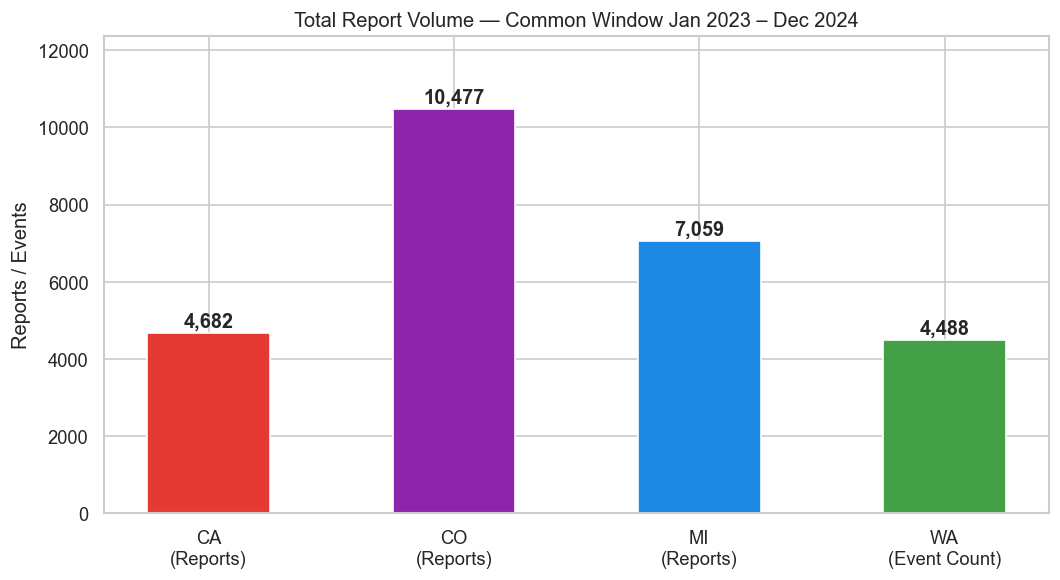

In [4]:
totals = {
    'CA\n(Reports)':     len(ca),
    'CO\n(Reports)':     len(co),
    'MI\n(Reports)':     len(mi),
    'WA\n(Event Count)': int(wa['Adverse Event Count'].sum()),
}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(totals.keys(), totals.values(),
              color=[STATE_COLORS[k] for k in ['CA', 'CO', 'MI', 'WA']],
              width=0.5)
for bar, val in zip(bars, totals.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Reports / Events')
ax.set_ylim(0, max(totals.values()) * 1.18)
ax.set_title('Total Report Volume — Common Window Jan 2023 – Dec 2024')
plt.tight_layout()
plt.show()

## 3 · Monthly Trend — CA · CO · MI (2023–2024)
> WA has year-level granularity only; it appears in Section 4.

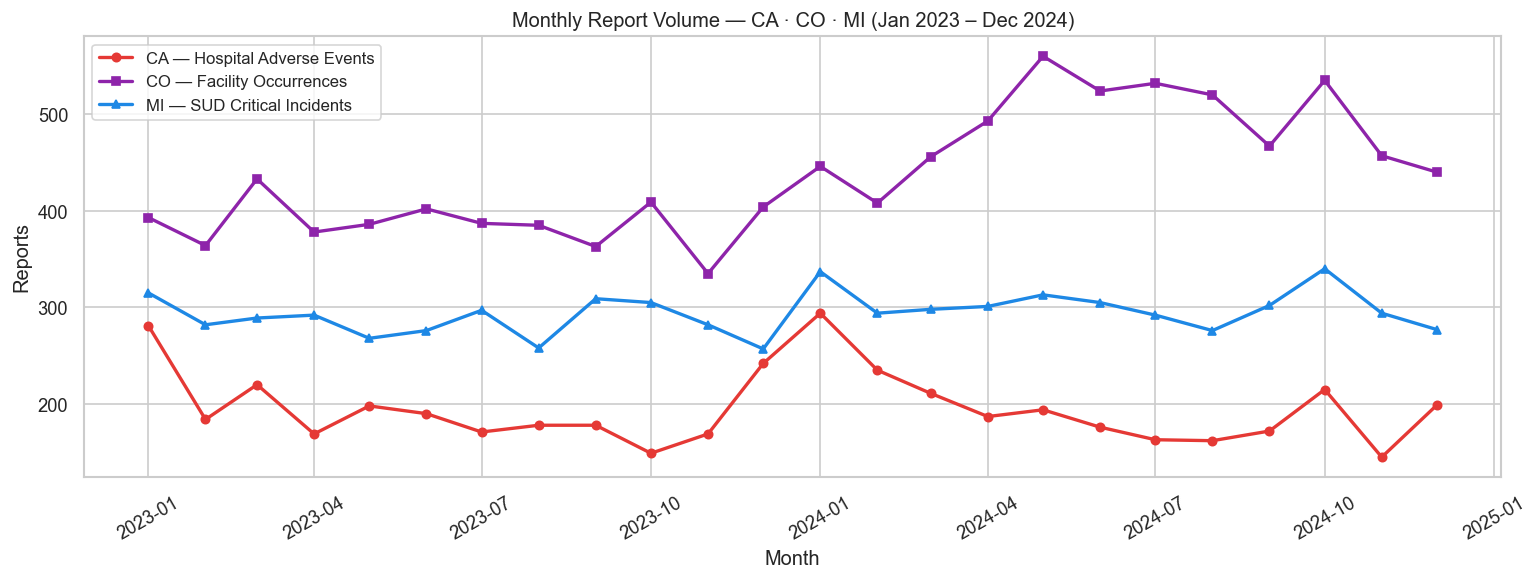

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
for state, df, marker, label in [
    ('CA', ca, 'o', 'CA — Hospital Adverse Events'),
    ('CO', co, 's', 'CO — Facility Occurrences'),
    ('MI', mi, '^', 'MI — SUD Critical Incidents'),
]:
    m = df.groupby('month').size()
    m.index = m.index.to_timestamp()
    ax.plot(m.index, m.values, marker=marker,
            color=STATE_COLORS[state], label=label, linewidth=2, markersize=5)

ax.set_xlabel('Month')
ax.set_ylabel('Reports')
ax.set_title('Monthly Report Volume — CA · CO · MI (Jan 2023 – Dec 2024)')
ax.legend(fontsize=10)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4 · Annual Comparison: 2023 vs 2024 — All Four States

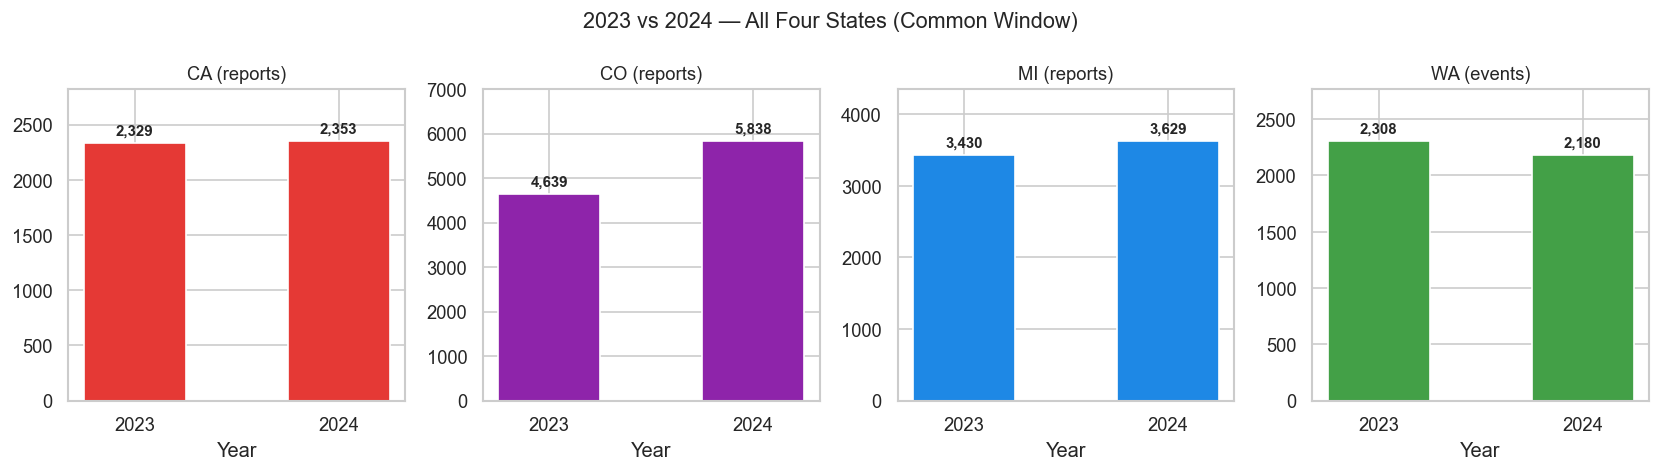

CA: 2023=2,329  2024=2,353  change=+1.0%
CO: 2023=4,639  2024=5,838  change=+25.8%
MI: 2023=3,430  2024=3,629  change=+5.8%
WA: 2023=2,308  2024=2,180  change=-5.5%


In [6]:
yearly = {
    'CA': ca.groupby('year').size(),
    'CO': co.groupby('year').size(),
    'MI': mi.groupby('year').size(),
    'WA': wa.groupby('Year')['Adverse Event Count'].sum().astype(int),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)
for ax, (state, series) in zip(axes, yearly.items()):
    bars = ax.bar([str(int(y)) for y in series.index], series.values,
                  color=STATE_COLORS[state], width=0.5)
    for bar, val in zip(bars, series.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + series.values.max() * 0.02,
                f'{int(val):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    suffix = ' (events)' if state == 'WA' else ' (reports)'
    ax.set_title(f'{state}{suffix}', fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylim(0, series.values.max() * 1.2)

plt.suptitle('2023 vs 2024 — All Four States (Common Window)', fontsize=13)
plt.tight_layout()
plt.show()

for state, series in yearly.items():
    vals = series.values
    if len(vals) == 2:
        chg = (vals[1] - vals[0]) / vals[0] * 100
        print(f'{state}: 2023={int(vals[0]):,}  2024={int(vals[1]):,}  change={chg:+.1f}%')

## 5 · Event Theme Distribution — Normalized (2023–2024)

In [7]:
THEMES = ['Care Management', 'Abuse / Criminal', 'Clinical / Procedural', 'Patient Safety', 'Environmental / Other']

CA_MAP = {'04 - Care Management Events':'Care Management','06 - Criminal Events':'Abuse / Criminal',
          '01 - Surgical Events':'Clinical / Procedural','02 - Product or Device Events':'Clinical / Procedural',
          '07 - Other':'Environmental / Other','05 - Environmental Events':'Environmental / Other',
          '03 - Patient Protection Events':'Patient Safety'}
CO_MAP = {'Physical Abuse':'Abuse / Criminal','Sexual Abuse':'Abuse / Criminal','Verbal Abuse':'Abuse / Criminal',
          'Misappropriation of Property':'Abuse / Criminal','Missing Person':'Patient Safety',
          'Neglect':'Care Management','Death':'Care Management','Brain Injury':'Care Management',
          'Diverted Drugs':'Clinical / Procedural','Equipment Malfunction':'Clinical / Procedural',
          'Equipment Misuse':'Clinical / Procedural',
          'Life Threatening Anesthesia Complications or Reactions':'Clinical / Procedural'}
MI_MAP = {'Non-Suicide Death':'Care Management','Emergency Medical Treatment':'Care Management',
          'Death of Unknown Cause':'Care Management','Hospitalization':'Care Management',
          'Suicide':'Patient Safety','Arrest':'Abuse / Criminal',
          'Serious Challenging Behaviors':'Abuse / Criminal','MAT Medication Error':'Clinical / Procedural'}
WA_MAP = {'Care Management Events':'Care Management','Procedure Events':'Clinical / Procedural',
          'Products or Devices':'Clinical / Procedural','Radiologic Events':'Clinical / Procedural',
          'Criminal Events':'Abuse / Criminal','Environmental Events':'Environmental / Other',
          'Patient Protection':'Patient Safety'}

ca_t = ca['AE_CATEGORY'].map(CA_MAP).value_counts().reindex(THEMES, fill_value=0)
co_t = co['Type of Occurrence'].map(CO_MAP).value_counts().reindex(THEMES, fill_value=0)
mi_t = mi['Event Type'].map(MI_MAP).value_counts().reindex(THEMES, fill_value=0)
wa_t = (wa.groupby('Event Type')['Adverse Event Count'].sum()
          .rename(WA_MAP).groupby(level=0).sum()
          .reindex(THEMES, fill_value=0).astype(int))

theme_raw = pd.DataFrame({'CA': ca_t, 'CO': co_t, 'MI': mi_t, 'WA': wa_t})
theme_pct = theme_raw.div(theme_raw.sum()).mul(100).round(1)

print('Raw counts per theme (2023–2024):')
print(theme_raw.to_string())
print()
print('Share of each state total (%):')
print(theme_pct.to_string())

Raw counts per theme (2023–2024):
                         CA    CO    MI    WA
Care Management        3093  1857  6336  3518
Abuse / Criminal        552  6525   552   280
Clinical / Procedural   552   567     3   508
Patient Safety           20  1516   168   110
Environmental / Other   465     0     0    72

Share of each state total (%):
                         CA    CO    MI    WA
Care Management        66.1  17.7  89.8  78.4
Abuse / Criminal       11.8  62.4   7.8   6.2
Clinical / Procedural  11.8   5.4   0.0  11.3
Patient Safety          0.4  14.5   2.4   2.5
Environmental / Other   9.9   0.0   0.0   1.6


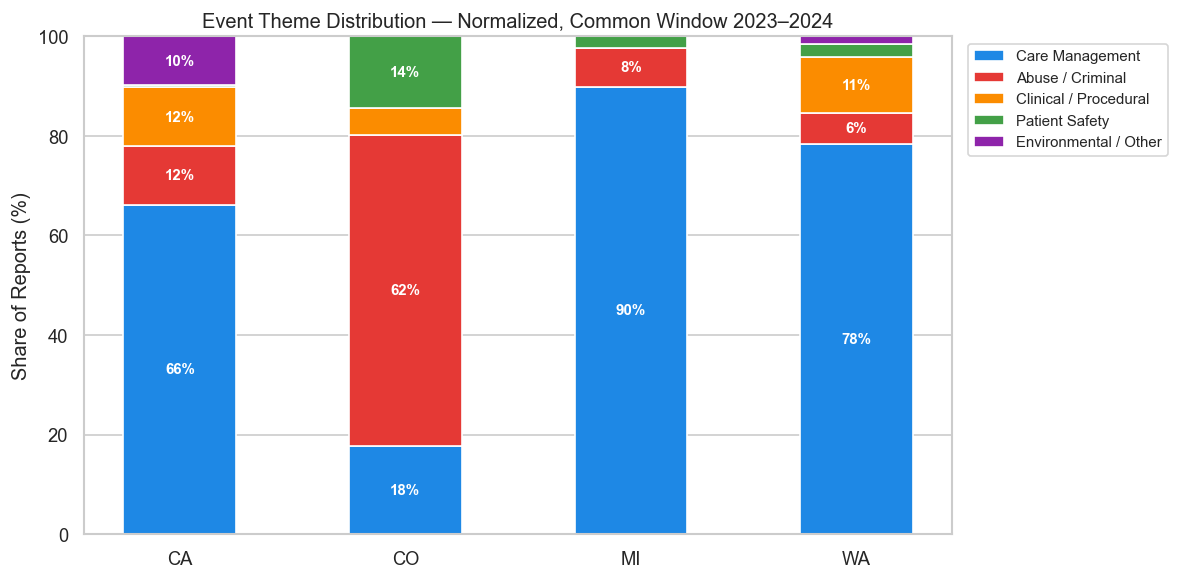

In [8]:
THEME_COLORS = ['#1E88E5', '#E53935', '#FB8C00', '#43A047', '#8E24AA']
states   = ['CA', 'CO', 'MI', 'WA']
bottoms  = [0] * 4

fig, ax = plt.subplots(figsize=(10, 5))
for theme, color in zip(THEMES, THEME_COLORS):
    vals = [theme_pct.loc[theme, s] for s in states]
    bars = ax.bar(states, vals, bottom=bottoms, label=theme, color=color, width=0.5)
    for bar, val, bot in zip(bars, vals, bottoms):
        if val >= 6:
            ax.text(bar.get_x() + bar.get_width() / 2, bot + val / 2,
                    f'{val:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.set_ylabel('Share of Reports (%)')
ax.set_title('Event Theme Distribution — Normalized, Common Window 2023–2024')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 6 · Top 5 Event Types per State (2023–2024)

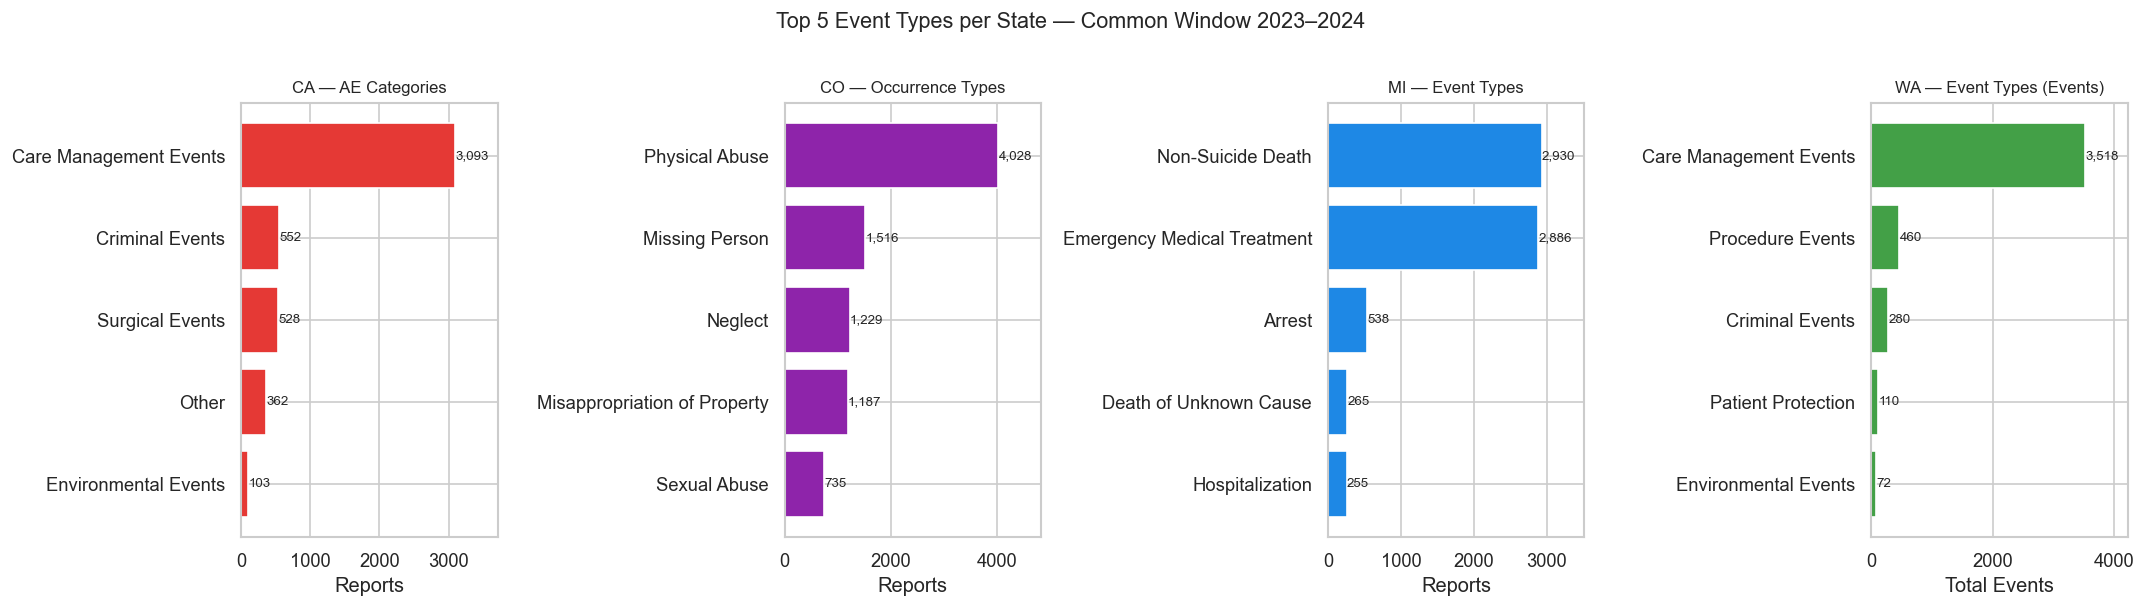

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# CA
ca_top = ca['AE_CATEGORY'].str.replace(r'^\d{2} - ', '', regex=True).value_counts().head(5)
axes[0].barh(ca_top.index.str[:30], ca_top.values, color=STATE_COLORS['CA'])
for bar, val in zip(axes[0].patches, ca_top.values):
    axes[0].text(val + 5, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center', fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlim(0, ca_top.max() * 1.2)
axes[0].set_title('CA — AE Categories', fontsize=10)
axes[0].set_xlabel('Reports')

# CO
co_top = co['Type of Occurrence'].value_counts().head(5)
axes[1].barh(co_top.index.str[:30], co_top.values, color=STATE_COLORS['CO'])
for bar, val in zip(axes[1].patches, co_top.values):
    axes[1].text(val + 5, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center', fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlim(0, co_top.max() * 1.2)
axes[1].set_title('CO — Occurrence Types', fontsize=10)
axes[1].set_xlabel('Reports')

# MI
mi_top = mi['Event Type'].value_counts().head(5)
axes[2].barh(mi_top.index.str[:30], mi_top.values, color=STATE_COLORS['MI'])
for bar, val in zip(axes[2].patches, mi_top.values):
    axes[2].text(val + 5, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center', fontsize=8)
axes[2].invert_yaxis()
axes[2].set_xlim(0, mi_top.max() * 1.2)
axes[2].set_title('MI — Event Types', fontsize=10)
axes[2].set_xlabel('Reports')

# WA
wa_top = wa.groupby('Event Type')['Adverse Event Count'].sum().astype(int).sort_values(ascending=False).head(5)
axes[3].barh(wa_top.index.str[:30], wa_top.values, color=STATE_COLORS['WA'])
for bar, val in zip(axes[3].patches, wa_top.values):
    axes[3].text(val + 5, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center', fontsize=8)
axes[3].invert_yaxis()
axes[3].set_xlim(0, wa_top.max() * 1.2)
axes[3].set_title('WA — Event Types (Events)', fontsize=10)
axes[3].set_xlabel('Total Events')

plt.suptitle('Top 5 Event Types per State — Common Window 2023–2024', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7 · Abuse / Criminal Reports — 2023–2024

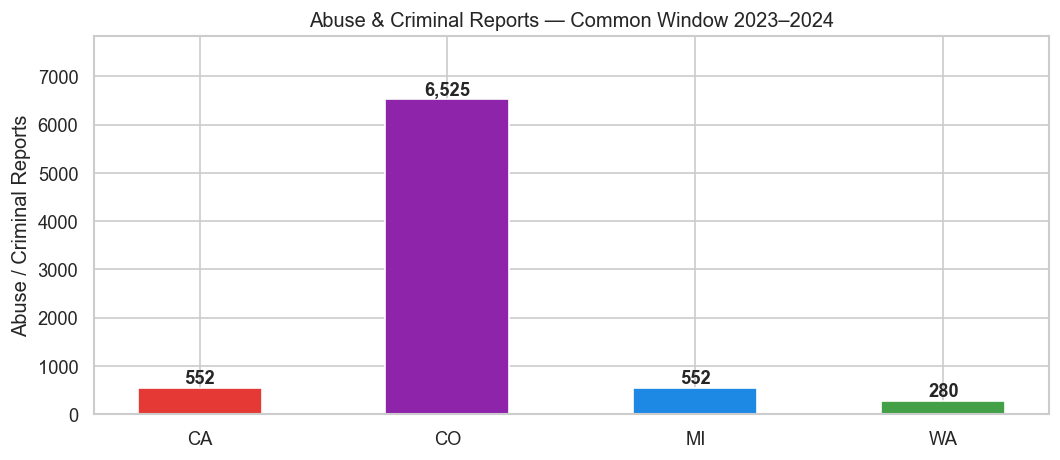

Abuse/Criminal share of each state's total (2023-2024):
  CA: 552 out of 4,682 (11.8%)
  CO: 6,525 out of 10,477 (62.3%)
  MI: 552 out of 7,059 (7.8%)
  WA: 280 out of 4,488 (6.2%)


In [10]:
abuse = {
    'CA': int((ca['AE_CATEGORY'] == '06 - Criminal Events').sum()),
    'CO': int(co['Type of Occurrence'].isin(['Physical Abuse','Sexual Abuse','Verbal Abuse','Misappropriation of Property']).sum()),
    'MI': int(mi['Event Type'].isin(['Arrest','Serious Challenging Behaviors']).sum()),
    'WA': int(wa[wa['Event Type'] == 'Criminal Events']['Adverse Event Count'].sum()),
}
totals_all = {'CA': len(ca), 'CO': len(co), 'MI': len(mi),
              'WA': int(wa['Adverse Event Count'].sum())}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(abuse.keys(), abuse.values(),
              color=[STATE_COLORS[k] for k in abuse], width=0.5)
for bar, (state, val) in zip(bars, abuse.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Abuse / Criminal Reports')
ax.set_ylim(0, max(abuse.values()) * 1.2)
ax.set_title('Abuse & Criminal Reports — Common Window 2023–2024')
plt.tight_layout()
plt.show()

print('Abuse/Criminal share of each state\'s total (2023-2024):')
for state, val in abuse.items():
    total = totals_all[state]
    print(f'  {state}: {val:,} out of {total:,} ({val/total*100:.1f}%)')

## 8 · Care Management vs Abuse / Criminal — 2023–2024

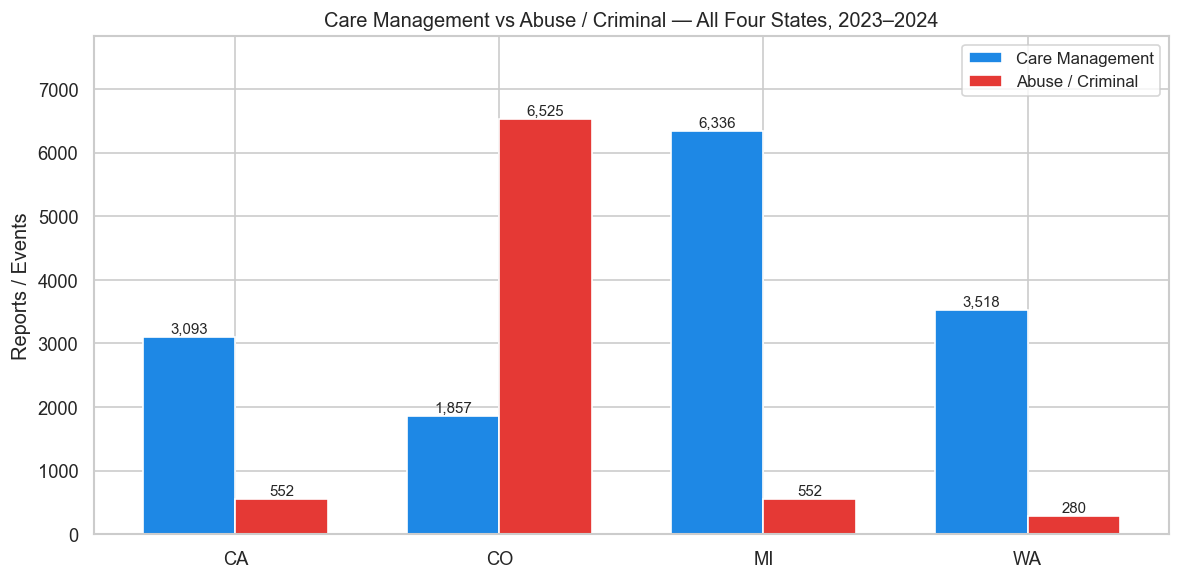

In [11]:
states  = ['CA', 'CO', 'MI', 'WA']
care    = [int(theme_raw.loc['Care Management',  s]) for s in states]
abuse_v = [int(theme_raw.loc['Abuse / Criminal', s]) for s in states]

x, w = np.arange(4), 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w / 2, care,    w, label='Care Management',  color='#1E88E5')
b2 = ax.bar(x + w / 2, abuse_v, w, label='Abuse / Criminal', color='#E53935')

for bar, val in zip(b1.patches, care):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(b2.patches, abuse_v):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(states)
ax.set_ylabel('Reports / Events')
ax.set_title('Care Management vs Abuse / Criminal — All Four States, 2023–2024')
ax.legend(fontsize=10)
ax.set_ylim(0, max(max(care), max(abuse_v)) * 1.2)
plt.tight_layout()
plt.show()

## 9 · Top Facilities per State — 2023–2024

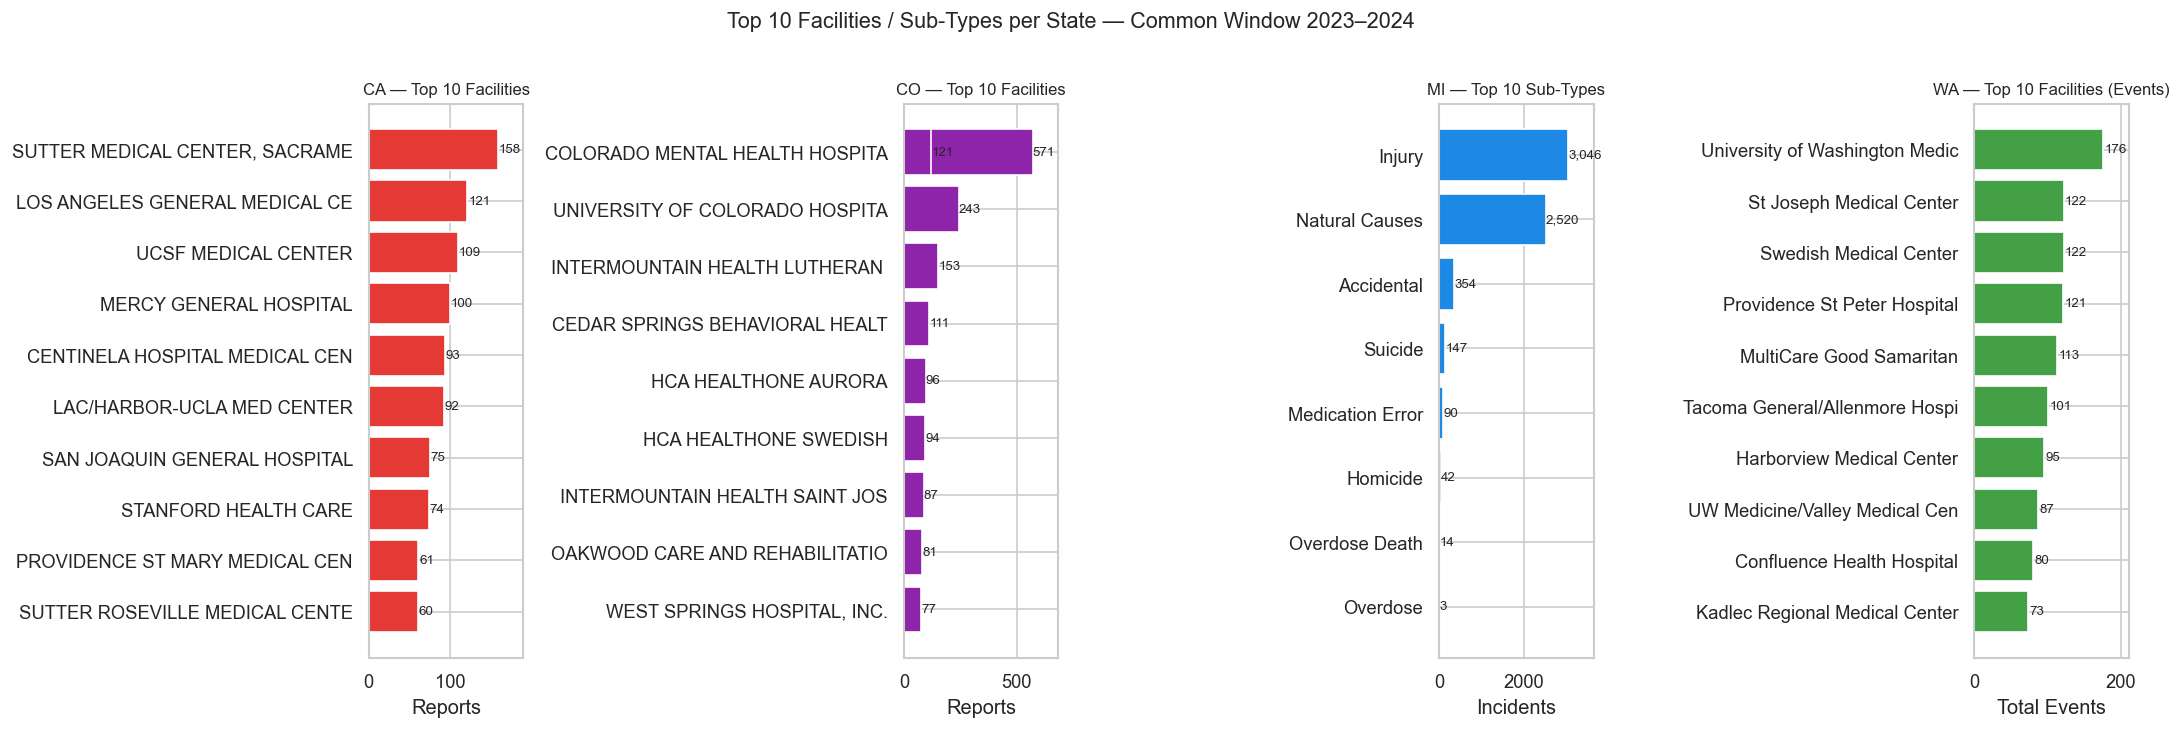

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# CA
ca_fac = ca.groupby('NAME').size().nlargest(10)
axes[0].barh(ca_fac.index.str[:30], ca_fac.values, color=STATE_COLORS['CA'])
for bar, val in zip(axes[0].patches, ca_fac.values):
    axes[0].text(val + 1, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center', fontsize=8)
axes[0].invert_yaxis(); axes[0].set_title('CA — Top 10 Facilities', fontsize=10)
axes[0].set_xlabel('Reports')
axes[0].set_xlim(0, ca_fac.max() * 1.2)

# CO
co_fac = co.groupby('Facility Name').size().nlargest(10)
axes[1].barh(co_fac.index.str[:30], co_fac.values, color=STATE_COLORS['CO'])
for bar, val in zip(axes[1].patches, co_fac.values):
    axes[1].text(val + 1, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center', fontsize=8)
axes[1].invert_yaxis(); axes[1].set_title('CO — Top 10 Facilities', fontsize=10)
axes[1].set_xlabel('Reports')
axes[1].set_xlim(0, co_fac.max() * 1.2)

# MI — no facility column; use Event Type as proxy
mi_sub = mi['Event Sub-Type'].value_counts().head(10)
axes[2].barh(mi_sub.index.str[:30], mi_sub.values, color=STATE_COLORS['MI'])
for bar, val in zip(axes[2].patches, mi_sub.values):
    axes[2].text(val + 5, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center', fontsize=8)
axes[2].invert_yaxis(); axes[2].set_title('MI — Top 10 Sub-Types', fontsize=10)
axes[2].set_xlabel('Incidents')
axes[2].set_xlim(0, mi_sub.max() * 1.2)

# WA
wa_fac = wa.groupby('Facility Name')['Adverse Event Count'].sum().astype(int).nlargest(10)
axes[3].barh(wa_fac.index.str[:30], wa_fac.values, color=STATE_COLORS['WA'])
for bar, val in zip(axes[3].patches, wa_fac.values):
    axes[3].text(val + 2, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center', fontsize=8)
axes[3].invert_yaxis(); axes[3].set_title('WA — Top 10 Facilities (Events)', fontsize=10)
axes[3].set_xlabel('Total Events')
axes[3].set_xlim(0, wa_fac.max() * 1.2)

plt.suptitle('Top 10 Facilities / Sub-Types per State — Common Window 2023–2024', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()